# End Term Report – CH248 (Molecular Systems Biology)

This Jupyter notebook consists of all codes used in modeling and figure plotting for the end term report of the course **CH248 (Molecular Systems Biology)**.

---

**Project Name:** *Modeling of Terminal Patterning in the Early Embryo of Drosophila Melanogaster*  
**Author:** Shravani Deoghare  
**Sr No:** 22103  
**Session:** Spring, 2025


### Figure 1: Spatio-temporal dynamics of Trunk signalling

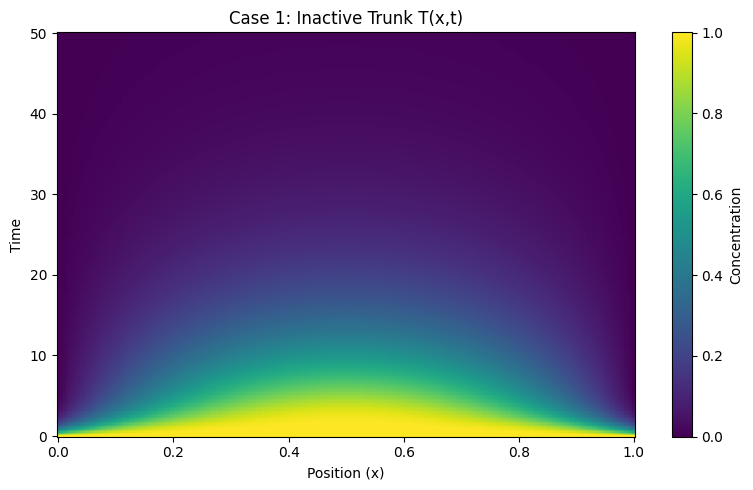

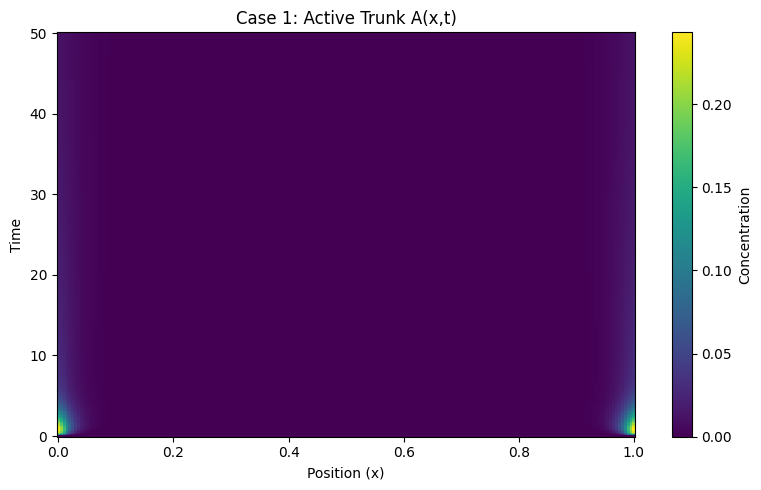

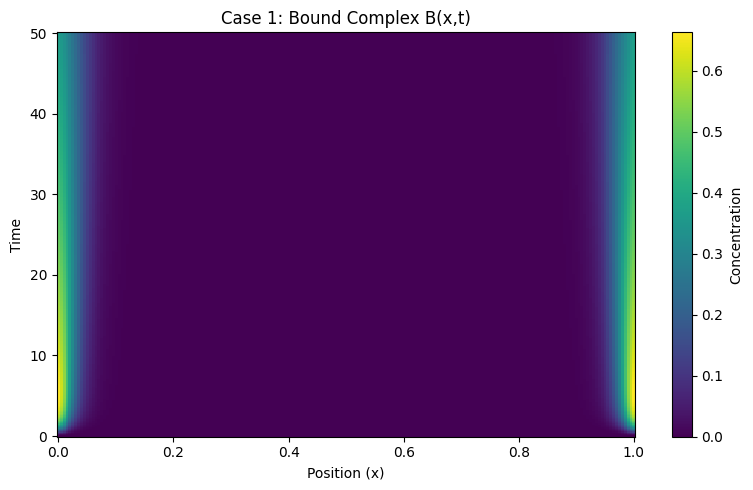

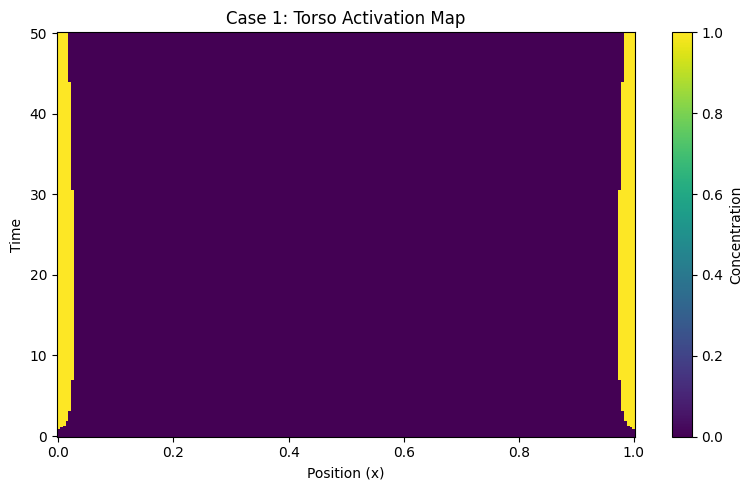

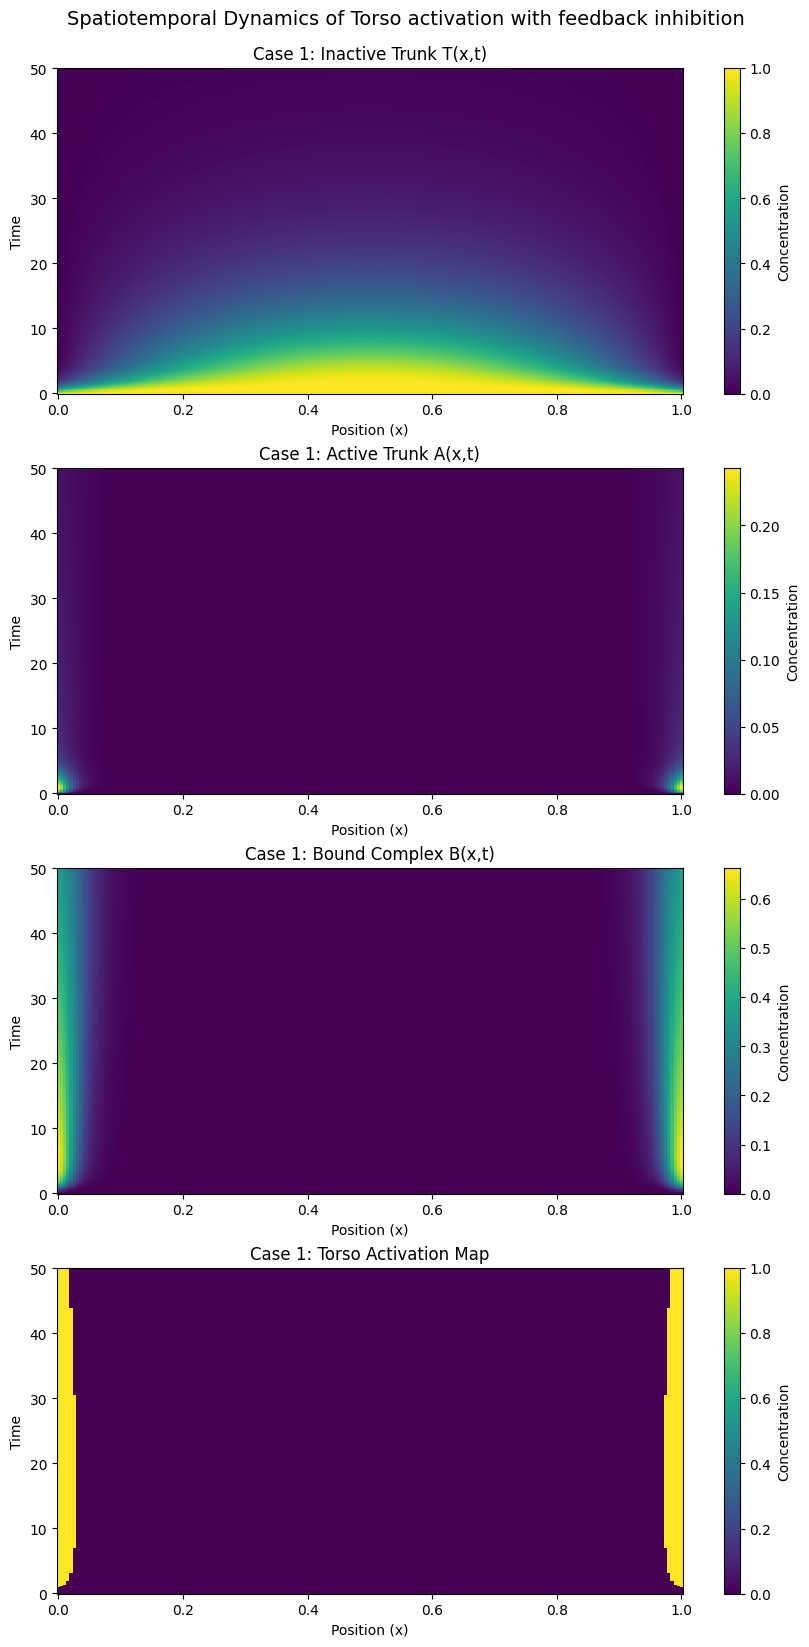

In [46]:
# Figure 1(A): CASE 1: Tls - Trk - Tor interaction

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----- PARAMETERS -----
D_T = 0.01        # Diffusion coefficient of inactive Trunk
D_A = 0.0005      # Diffusion coefficient of active Trunk
k_cleave = 1.0    # Cleavage rate of Trunk by Torso-like
k_deg_A = 0.4     # Degradation rate of active Trunk
k_on = 2.0        # Binding rate of active Trunk to receptor
k_off = 0.05      # Unbinding rate of ligand-receptor complex
R_tot = 1.0       # Total receptor concentration
threshold = 0.3   # Threshold for Torso activation
T0_total = 1.0    # Total initial concentration of Trunk
L = 1.0           # Domain length
nx = 200          # Number of spatial points
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

t_span = (0, 50)
t_eval = np.linspace(*t_span, 300)

# ----- TORSO-LIKE PROFILE -----
def torso_like(x, width=0.01):
    return np.where((x <= width) | (x >= 1 - width), 1.0, 0.0)
TL = torso_like(x, width=dx*2)

# ----- INITIAL CONDITIONS :Case 1 -----
def initialize():
    T = np.full(nx, T0_total / L)  # uniform trunk
    A = np.zeros(nx)
    B = np.zeros(nx)
    return np.concatenate([T, A, B])

# ----- SYSTEM OF EQUATIONS -----
def system(t, y):
    T = y[0:nx]
    A = y[nx:2*nx]
    B = y[2*nx:3*nx]
    
    dT = np.zeros(nx)
    dA = np.zeros(nx)
    dB = np.zeros(nx)

    # Laplacian for diffusion
    def laplacian(u):
        d2 = np.zeros_like(u)
        d2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        return d2

    # Diffusion
    dT += D_T * laplacian(T)
    dA += D_A * laplacian(A)
    
    # Cleavage by Torso-like profile
    reaction = k_cleave * TL * T
    dT -= reaction
    dA += reaction
    
    # Binding/unbinding to receptor
    R_free = R_tot - B
    bind = k_on * A * R_free
    unbind = k_off * B
    dA -= (bind - unbind)
    dB += (bind - unbind)
    
    # Degradation of active trunk
    dA -= k_deg_A * A
    
    return np.concatenate([dT, dA, dB])

# ----- RUN SIMULATION (Case 1) -----
y0 = initialize()
sol = solve_ivp(system, t_span, y0, t_eval=t_eval, method='RK45')
T_sol = sol.y[0:nx, :]
A_sol = sol.y[nx:2*nx, :]
B_sol = sol.y[2*nx:3*nx, :]
activation = (B_sol >= threshold).astype(float)

# ----- PLOTTING -----
def plot_spatiotemporal(data, x, t, title):
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(x, t, data.T, shading='auto')
    plt.xlabel('Position (x)')
    plt.ylabel('Time')
    plt.title(title)
    plt.colorbar(label='Concentration')
    plt.tight_layout()
    plt.show()

# Plot results for Case 1
plot_spatiotemporal(T_sol, x, sol.t, "Case 1: Inactive Trunk T(x,t)")
plot_spatiotemporal(A_sol, x, sol.t, "Case 1: Active Trunk A(x,t)")
plot_spatiotemporal(B_sol, x, sol.t, "Case 1: Bound Complex B(x,t)")
plot_spatiotemporal(activation, x, sol.t, "Case 1: Torso Activation Map")


# Call the new combined plotting function
plot_all_spatiotemporal(T_sol, A_sol, B_sol, activation, x, sol.t)



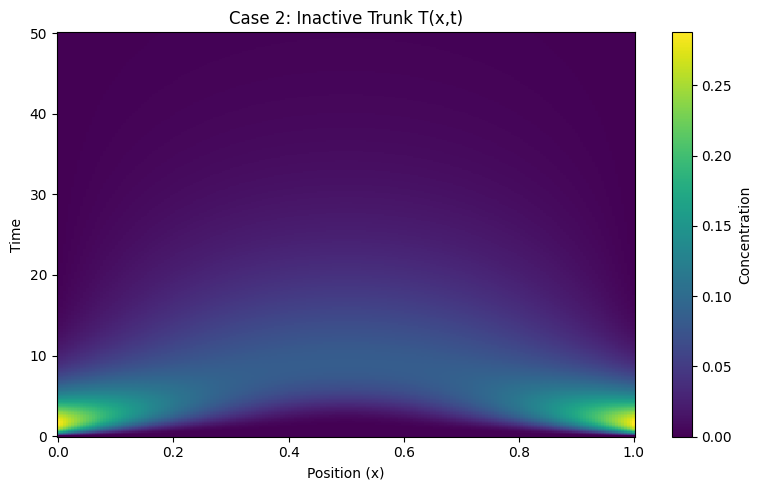

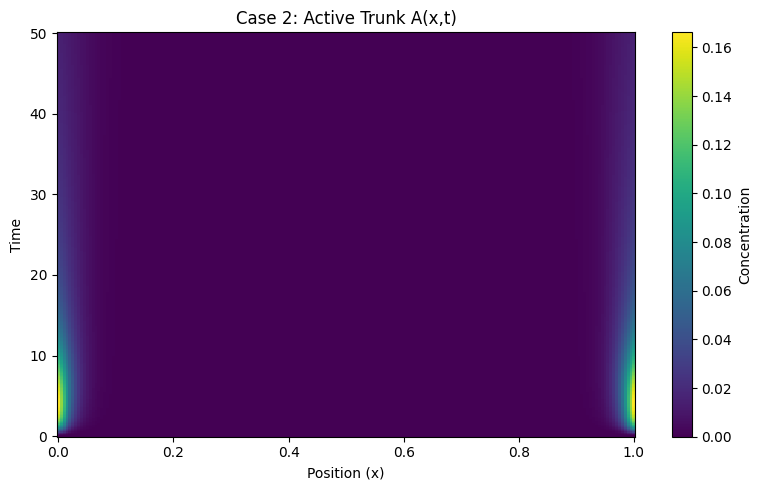

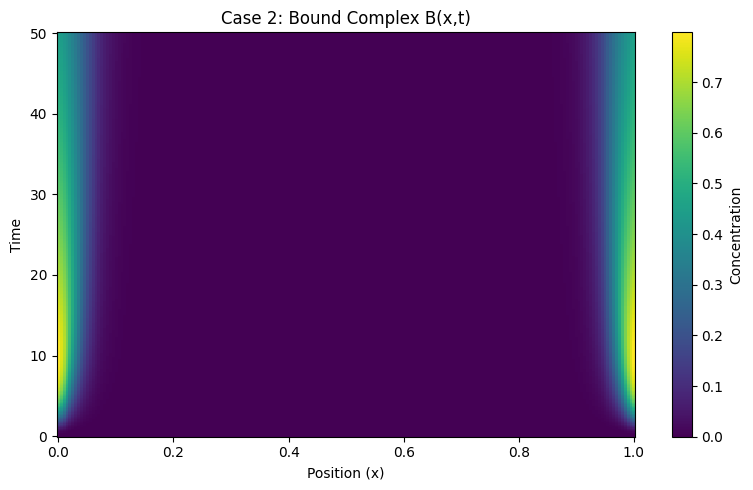

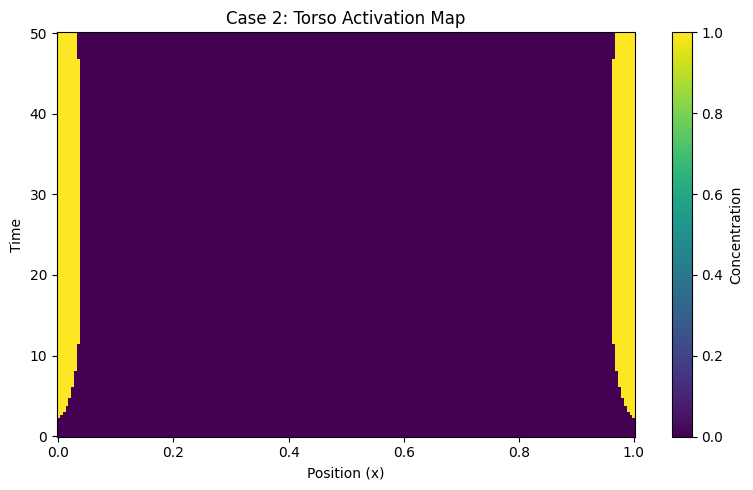

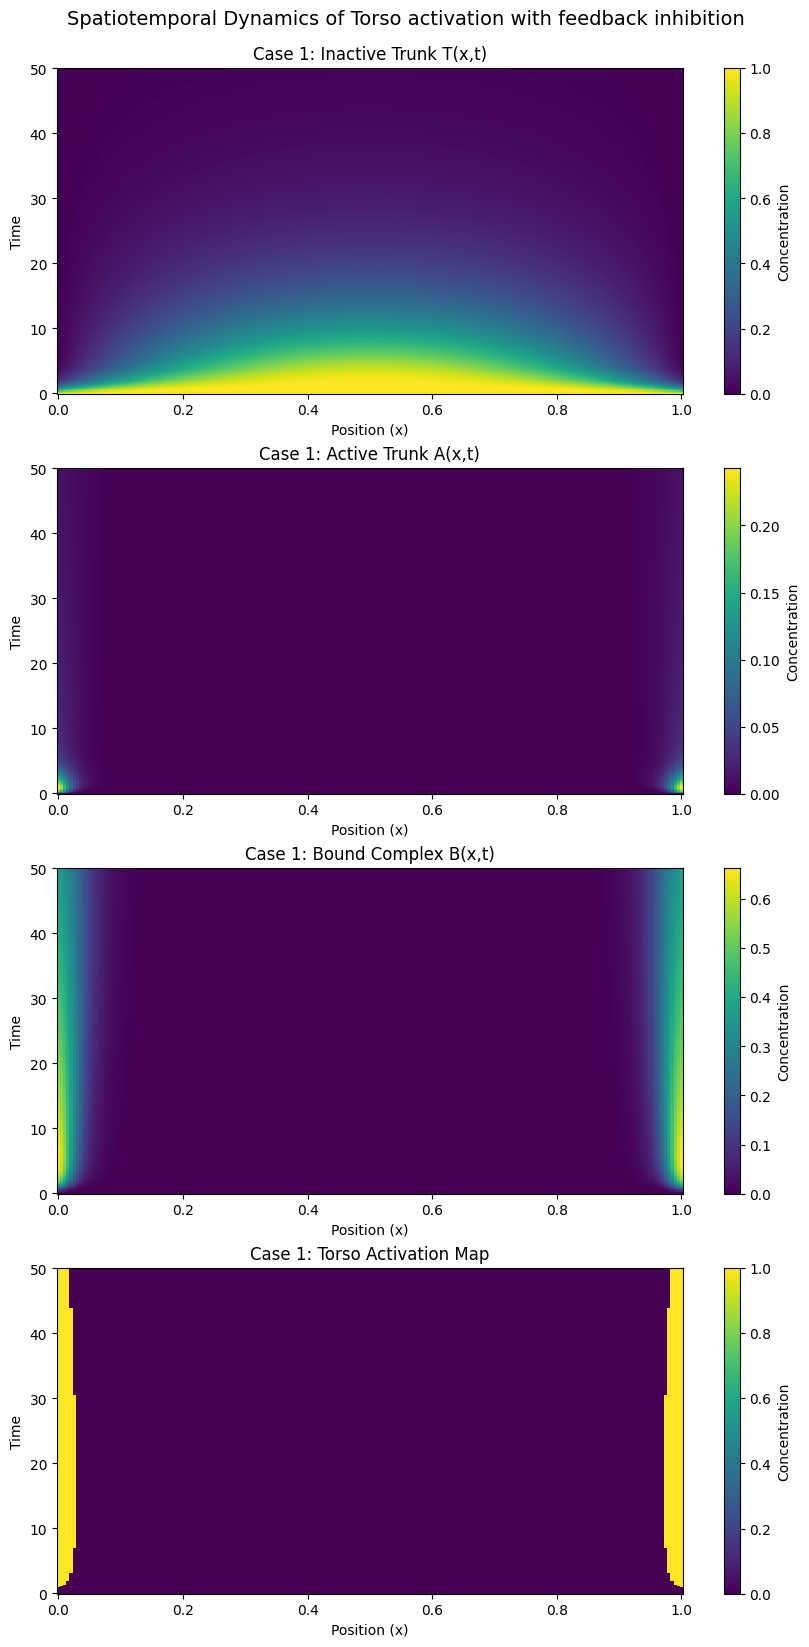

In [47]:
# Figure 1(B): CASE 2: Tls - Trk - Tor interaction

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----- PARAMETERS -----
D_T = 0.01
D_A = 0.0005
k_cleave = 1.0
k_deg_A = 0.4
k_on = 2.0
k_off = 0.05
R_tot = 1.0
threshold = 0.3
L = 1.0
nx = 200
x = np.linspace(0, L, nx)
dx = x[1] - x[0]
t_span = (0.01, 50)  # start from 0.01 to avoid division by zero
t_eval = np.linspace(*t_span, 300)

# ----- TORSO-LIKE PROFILE -----
def torso_like(x, width=0.01):
    return np.where((x <= width) | (x >= 1 - width), 1.0, 0.0)

TL = torso_like(x, width=dx*2)

# ----- INITIAL CONDITIONS (Case 2: Zero initial T, influx at boundaries) -----
def initialize_case2():
    T = np.zeros(nx)
    A = np.zeros(nx)
    B = np.zeros(nx)
    return np.concatenate([T, A, B])

# ----- SYSTEM WITH INFLUX FOR CASE 2 -----
def system_case2(t, y):
    T = y[0:nx]
    A = y[nx:2*nx]
    B = y[2*nx:3*nx]
    
    dT = np.zeros(nx)
    dA = np.zeros(nx)
    dB = np.zeros(nx)

    def laplacian(u):
        d2 = np.zeros_like(u)
        d2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        return d2

    dT += D_T * laplacian(T)
    dA += D_A * laplacian(A)

    reaction = k_cleave * TL * T
    dT -= reaction
    dA += reaction

    R_free = R_tot - B
    bind = k_on * A * R_free
    unbind = k_off * B
    dA -= bind - unbind
    dB += bind - unbind

    dA -= k_deg_A * A

    # Trunk influx at ends (exponential time dependence)
    influx_rate = 0.5 * np.exp(-t/3)
    dT[0] += influx_rate
    dT[-1] += influx_rate

    return np.concatenate([dT, dA, dB])

# ----- RUN SIMULATION -----
def run_case2():
    y0 = initialize_case2()
    sol = solve_ivp(system_case2, t_span, y0, t_eval=t_eval, method='RK45')
    T_sol = sol.y[0:nx, :]
    A_sol = sol.y[nx:2*nx, :]
    B_sol = sol.y[2*nx:3*nx, :]
    activation = (B_sol >= threshold).astype(float)
    return x, sol.t, T_sol, A_sol, B_sol, activation

# ----- PLOTTING FUNCTION -----
def plot_spatiotemporal(data, x, t, title):
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(x, t, data.T, shading='auto')
    plt.xlabel('Position (x)')
    plt.ylabel('Time')
    plt.title(title)
    plt.colorbar(label='Concentration')
    plt.tight_layout()
    plt.show()

# Run and plot Case 2
x_vals, t_vals, T_vals, A_vals, B_vals, act = run_case2()
plot_spatiotemporal(T_vals, x_vals, t_vals, "Case 2: Inactive Trunk T(x,t)")
plot_spatiotemporal(A_vals, x_vals, t_vals, "Case 2: Active Trunk A(x,t)")
plot_spatiotemporal(B_vals, x_vals, t_vals, "Case 2: Bound Complex B(x,t)")
plot_spatiotemporal(act, x_vals, t_vals, "Case 2: Torso Activation Map")

# Call the new combined plotting function
plot_all_spatiotemporal(T_sol, A_sol, B_sol, activation, x, sol.t)


### Figure 2: Temporal Dynamics of Torso -> ERK signal cascade and feedback

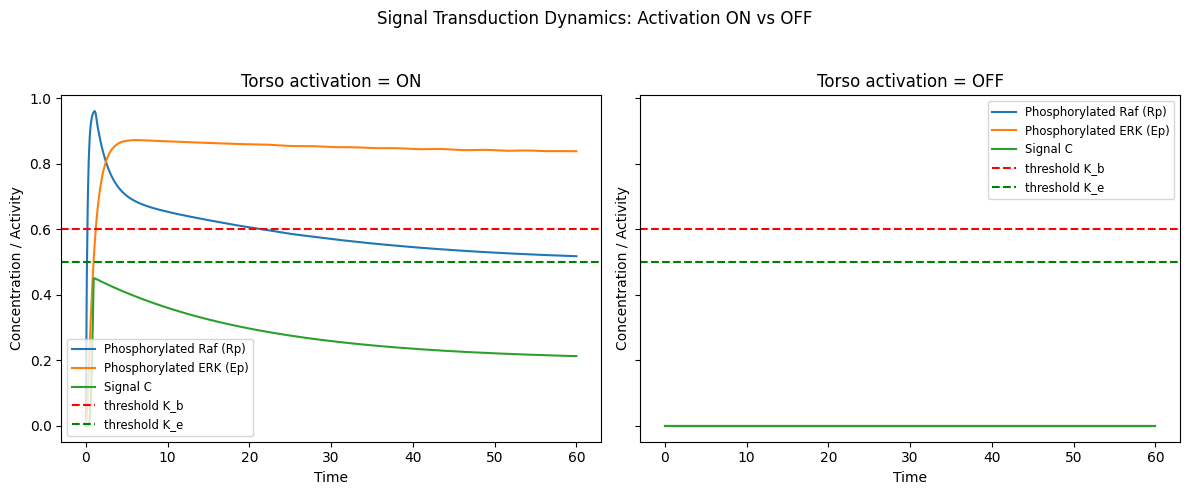

In [43]:
## This code models the signal transduction pathway from Torso to Raf to ERK to C 

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ----- PARAMETERS -----
V_c = 1.0         # Raf phosphorylation rate by signal C
alpha_r = 0.2     # Dephosphorylation rate of Raf_p
V_e = 1.0         # ERK phosphorylation rate by Raf_p
alpha_e = 0.1     # Dephosphorylation rate of ERK_p
beta0 = 0.01      # Basal production rate of C
beta = 2.0        # Maximal autoregulation rate of C by ERK_p
n = 4             # Hill coefficient for C expression
K_c = 0.4         # Hill constant for C expression
alpha_c = 0.05    # Degradation rate of C protein
K_b = 0.6         # ERK_p threshold to turn off Torso input
K_e = 0.5         # ERK_p threshold for feedback activation
b = 10            # Amount of torso-ligand complexes

R_tot = 1.0       # Total Raf
E_tot = 1.0       # Total ERK

def make_ode(V_b):
    def odes(t, y):
        Rp, Ep, C = y
        Ro = R_tot - Rp
        Eo = E_tot - Ep
        # switch off Torso-driven phosphorylation if Ep >= K_b
        Vb_eff = V_b if Ep < K_b else 0.0
        beta_eff = beta if Ep < K_e else 0.0
        beta0_eff = beta0 if Ep >= K_e else 0
        dRp = Vb_eff*(b/2)*Ro + V_c*C*Ro - alpha_r*Rp
        dEp = V_e * Rp * Eo - alpha_e * Ep
        dC  = beta0_eff + beta_eff * Ep**n / (Ep**n + K_c**n) - alpha_c * C
        return [dRp, dEp, dC]
    return odes

# ----- SIMULATION SETTINGS -----
y0 = [0.0, 0.0, 0.0]           # initial Rp, Ep, C
t_span = (0, 60)
t_eval = np.linspace(*t_span, 500)

# Solve for both V_b = 1 (ON) and V_b = 0 (OFF)
solutions = {}
for label, Vb_val in [('ON', 1.0), ('OFF', 0.0)]:
    sol = solve_ivp(make_ode(Vb_val), t_span, y0, t_eval=t_eval, method='RK45')
    solutions[label] = sol

# ----- PLOTTING SIDE BY SIDE -----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (label, sol) in zip(axes, solutions.items()):
    ax.plot(sol.t, sol.y[0], label='Phosphorylated Raf (Rp)')
    ax.plot(sol.t, sol.y[1], label='Phosphorylated ERK (Ep)')
    ax.plot(sol.t, sol.y[2], label='Signal C')
    ax.axhline(K_b, ls='--', label='threshold K_b' , color='red')
    ax.axhline(K_e, ls='--', label='threshold K_e', color='green')
    ax.set_title(f'Torso activation = {label}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Concentration / Activity')
    ax.legend(fontsize='small')

plt.suptitle('Signal Transduction Dynamics: Activation ON vs OFF')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Figure 3: Combined model of Torso activation by Trunk and feedback of subsequent downstream signalling

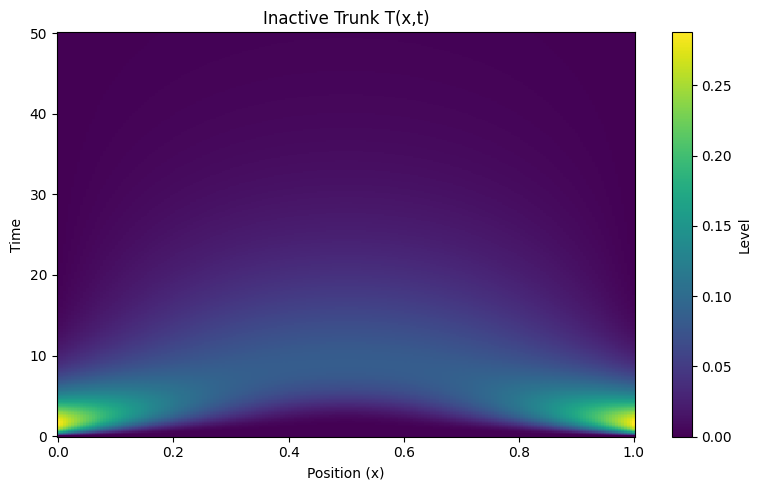

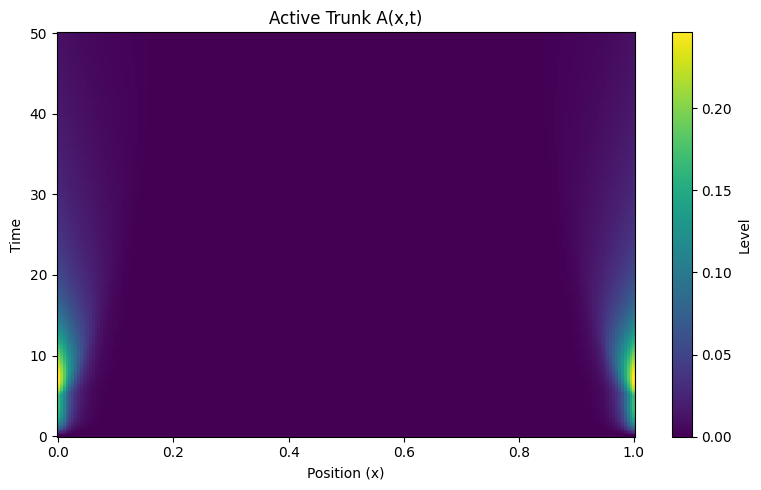

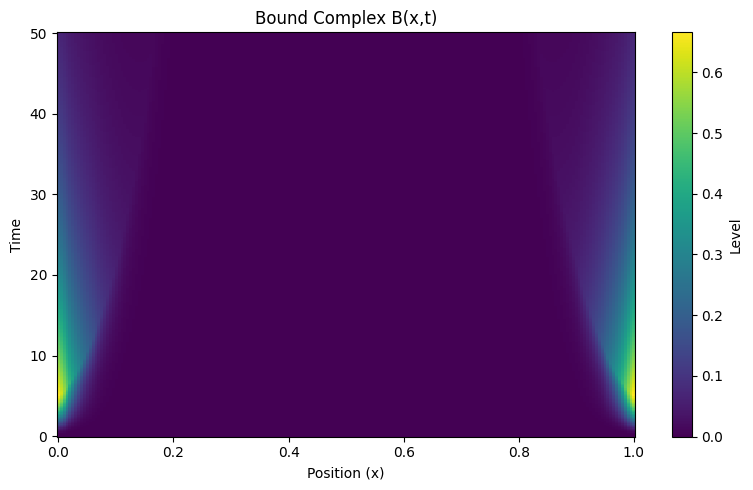

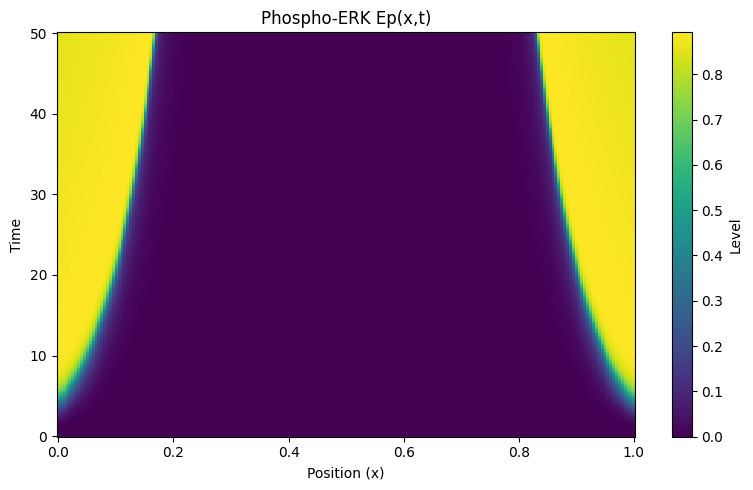

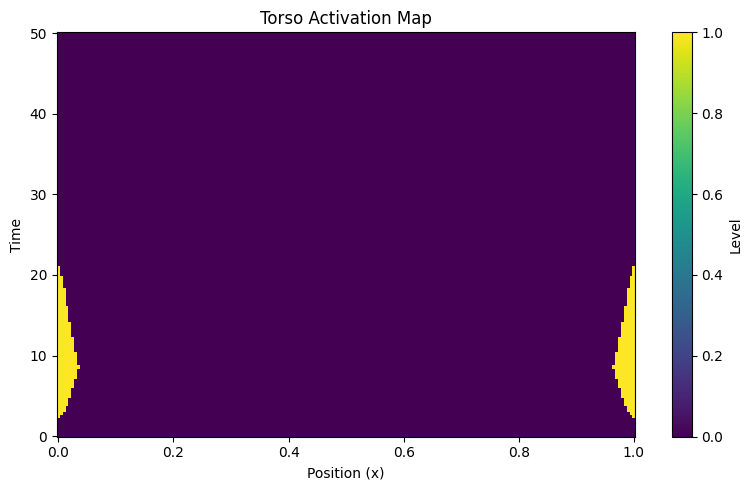

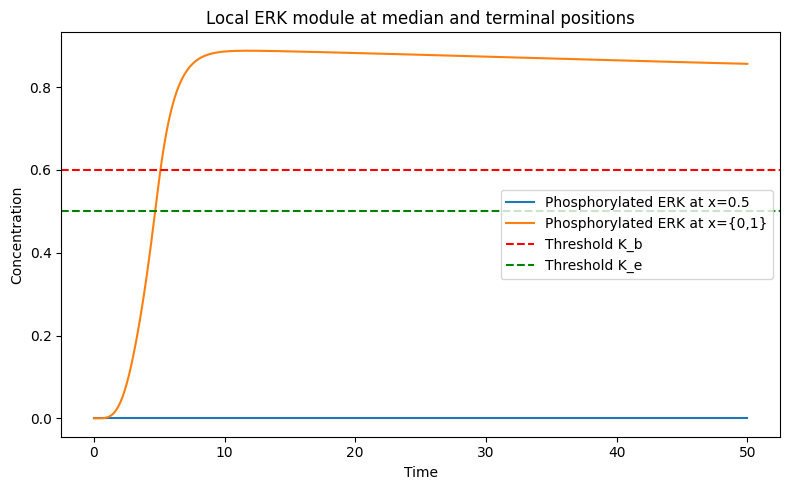

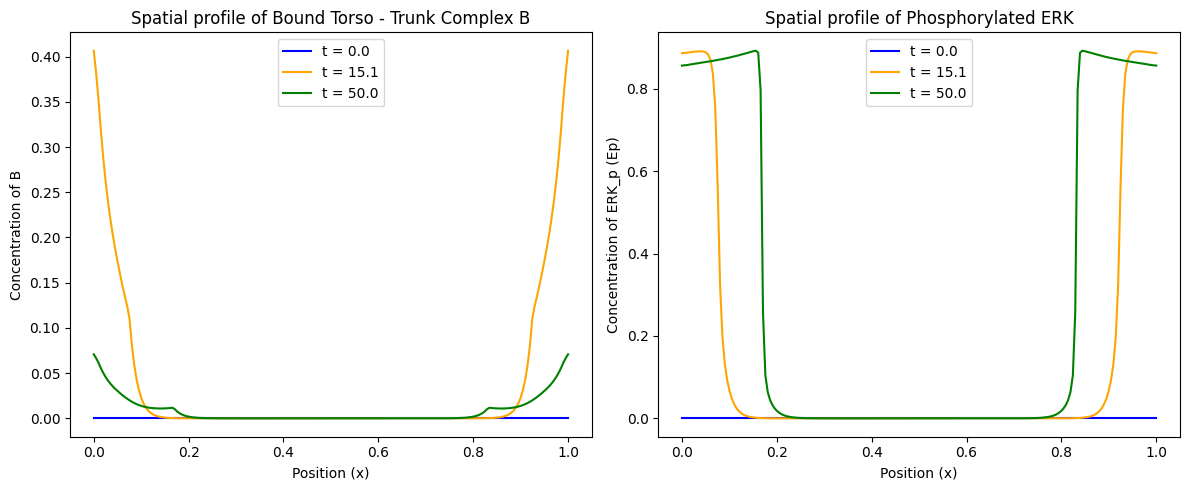

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----- PARAMETERS -----
# Spatial-PDE parameters
D_T = 0.01       # diffusion of inactive trunk
D_A = 0.0005     # diffusion of active trunk
k_cleave = 1.0   # cleavage rate of T to A
k_deg_A = 0.4    # degradation of A
k_on0 = 2.0      # basal binding rate of A to receptor
k_off = 0.05     # unbinding rate of complex B
R_tot = 1.0      # total receptor
threshold = 0.3  # activation threshold for B
L = 1.0          # domain length
nx = 200         # spatial grid points
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

t_span = (0.01, 50)
t_eval = np.linspace(*t_span, 300)

# Torso-like ligand profile
def torso_like(x, width=0.01):
    return np.where((x <= width) | (x >= 1 - width), 1.0, 0.0)
TL = torso_like(x, width=dx*2)

# ----- ERK Module parameters -----
V_b = 1         # Raf phosphorylation rate by Torso
V_c = 1.0         # Raf phosphorylation rate by signal C
alpha_r = 0.2     # Dephosphorylation rate of Raf_p
V_e = 1.0         # ERK phosphorylation rate by Raf_p
alpha_e = 0.1     # Dephosphorylation rate of ERK_p
beta0 = 0.01      # Basal production rate of C
beta = 2.0        # Maximal autoregulation rate of C by ERK_p
n = 4             # Hill coefficient for C expression
K_c = 0.4         # Hill constant for C expression
alpha_c = 0.05    # Degradation rate of C protein
K_b = 0.6         # ERK_p threshold to turn off Torso input
K_e = 0.5         # ERK_p threshold for feedback activation
# ----- INITIAL CONDITIONS -----
def initialize():
    # T, A, B fields
    T0 = np.zeros(nx)
    A0 = np.zeros(nx)
    B0 = np.zeros(nx)
    # Local ODEs: Rp, Ep, C (homogeneous initial)
    Rp0 = np.zeros(nx)
    Ep0 = np.zeros(nx)
    C0 = np.zeros(nx)
    return np.concatenate([T0, A0, B0, Rp0, Ep0, C0])

# ----- SYSTEM: PDE + local ODE at each x -----
def system_full(t, y):
    # unpack
    T = y[0:nx]
    A = y[nx:2*nx]
    B = y[2*nx:3*nx]
    Rp = y[3*nx:4*nx]
    Ep = y[4*nx:5*nx]
    C = y[5*nx:6*nx]

    # allocate derivatives
    dT = np.zeros(nx)
    dA = np.zeros(nx)
    dB = np.zeros(nx)
    dRp = np.zeros(nx)
    dEp = np.zeros(nx)
    dC = np.zeros(nx)

    # Laplacian for diffusion
    def laplacian(u):
        d2 = np.zeros_like(u)
        d2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        return d2

    # Diffusion
    dT += D_T * laplacian(T)
    dA += D_A * laplacian(A)

    # T -> A conversion
    reaction = k_cleave * TL * T
    dT -= reaction
    dA += reaction

    # Binding/unbinding for trunk-receptor complexes
    # k_on is turned off where Ep >= K_b
    k_on_eff = np.where(Ep < K_b, k_on0, 0.0)
    R_free = R_tot - B
    bind = k_on_eff * A * R_free
    unbind = k_off * B
    dA -= (bind - unbind)
    dB += (bind - unbind)

    # Degradation of A
    dA -= k_deg_A * A

    # Influx of T at boundaries
    influx = 0.5 * np.exp(-t/3)
    dT[0] += influx
    dT[-1] += influx

    # ----- local ODEs for ERK module at each x -----
    # Note: no diffusion for Rp, Ep, C
    Ro = R_tot - Rp
    Eo = E_tot - Ep
    # local torso-ligand B provides signal b(x)
    b_loc = B
    # effective rates
    Vb_eff = np.where(Ep < K_b, V_b, 0.0)
    beta_eff = np.where(Ep < K_e, beta, 0.0)
    beta0_eff = np.where(Ep >= K_e, beta0, 0.0)

    dRp = Vb_eff * (b_loc/2.0) * Ro + V_c * C * Ro - alpha_r * Rp
    dEp = V_e * Rp * Eo - alpha_e * Ep
    dC  = beta0_eff + beta_eff * Ep**n / (Ep**n + K_c**n) - alpha_c * C

    # pack
    return np.concatenate([dT, dA, dB, dRp, dEp, dC])

# ----- RUN SIMULATION -----
sol = solve_ivp(system_full, t_span, initialize(), t_eval=t_eval, method='RK45')
# unpack solutions
T_sol  = sol.y[0:nx, :]
A_sol  = sol.y[nx:2*nx, :]
B_sol  = sol.y[2*nx:3*nx, :]
Rp_sol = sol.y[3*nx:4*nx, :]
Ep_sol = sol.y[4*nx:5*nx, :]
C_sol  = sol.y[5*nx:6*nx, :]
activation = (B_sol >= threshold).astype(float)

# ----- PLOTTING -----
def plot_spatiotemporal(data, x, t, title, cmap='viridis'):
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(x, t, data.T, shading='auto', cmap=cmap)
    plt.xlabel('Position (x)')
    plt.ylabel('Time')
    plt.title(title)
    plt.colorbar(label='Level')
    plt.tight_layout()
    plt.show()

# Heatmaps
plot_spatiotemporal(T_sol, x, sol.t, "Inactive Trunk T(x,t)")
plot_spatiotemporal(A_sol, x, sol.t, "Active Trunk A(x,t)")
plot_spatiotemporal(B_sol, x, sol.t, "Bound Complex B(x,t)")
plot_spatiotemporal(Ep_sol, x, sol.t, "Phospho-ERK Ep(x,t)")
plot_spatiotemporal(activation, x, sol.t, "Torso Activation Map")


# Time series of ERK_p at median and terminal positions
mid = nx//2
plt.figure(figsize=(8,5))
plt.plot(sol.t, Ep_sol[mid], label='Phosphorylated ERK at x=0.5')
plt.plot(sol.t, Ep_sol[-1], label='Phosphorylated ERK at x={0,1}')
plt.axhline(K_b, ls='--', label='Threshold K_b', color='red')
plt.axhline(K_e, ls='--', label='Threshold K_e', color='green')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.title('Local ERK module at median and terminal positions')
plt.tight_layout()
plt.show()

# ----- SPATIAL LINE PLOTS AT t = 0, 15, 50 -----
times_to_plot = [0, 15, 50]
indices = [np.argmin(np.abs(sol.t - t)) for t in times_to_plot]
colors = ['blue', 'orange', 'green']
labels = [f't = {sol.t[i]:.1f}' for i in indices]

plt.figure(figsize=(12, 5))

# Plot B(x)
plt.subplot(1, 2, 1)
for i, c, label in zip(indices, colors, labels):
    plt.plot(x, B_sol[:, i], color=c, label=label)
plt.xlabel('Position (x)')
plt.ylabel('Concentration of B')
plt.title('Spatial profile of Bound Torso - Trunk Complex B')
plt.legend()

# Plot Ep(x)
plt.subplot(1, 2, 2)
for i, c, label in zip(indices, colors, labels):
    plt.plot(x, Ep_sol[:, i], color=c, label=label)
plt.xlabel('Position (x)')
plt.ylabel('Concentration of ERK_p (Ep)')
plt.title('Spatial profile of Phosphorylated ERK')
plt.legend()

plt.tight_layout()
plt.show()




#### Supplementary: Combined model (case 1 + ERK feedback)

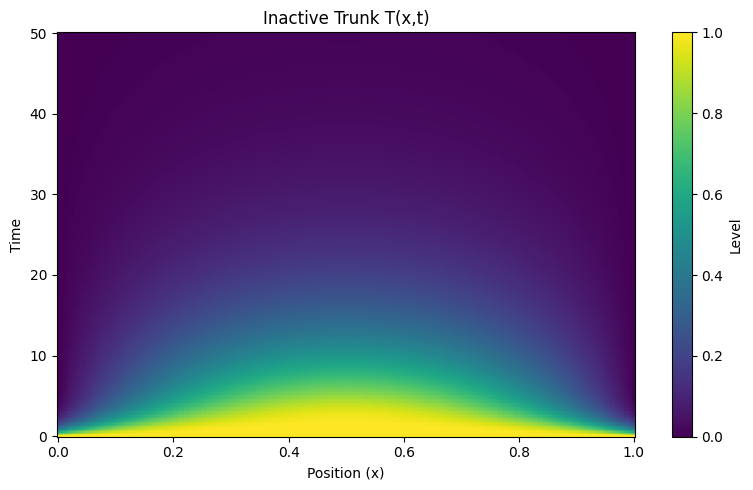

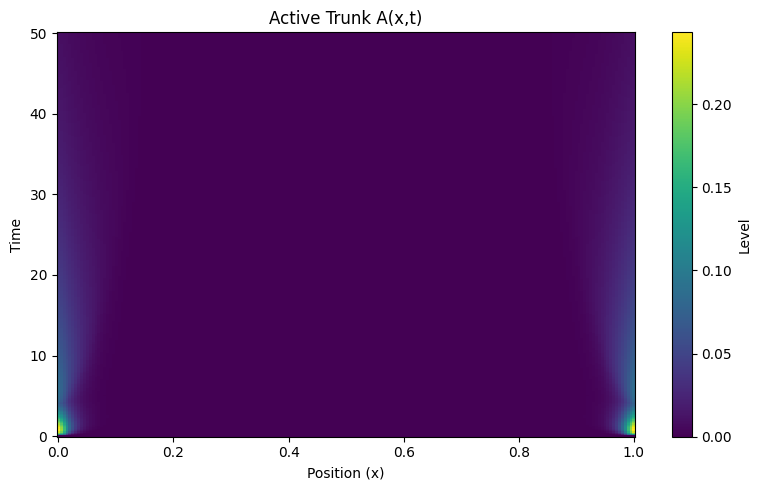

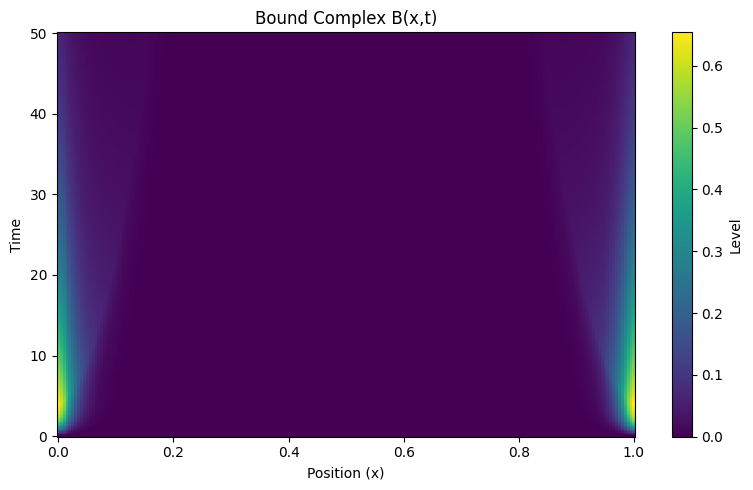

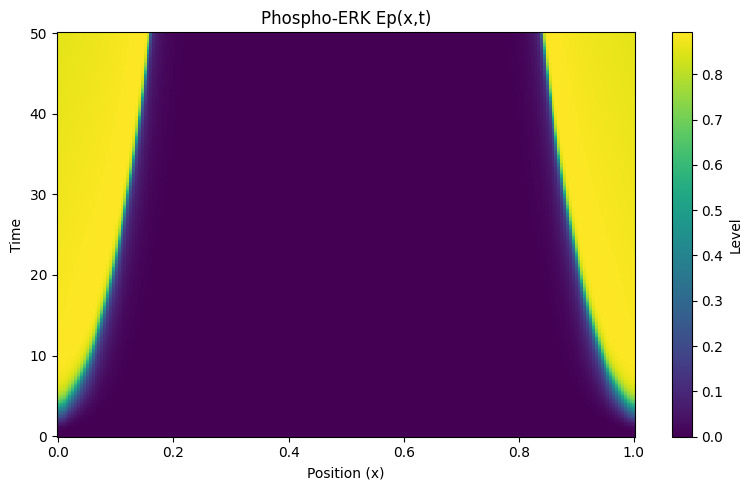

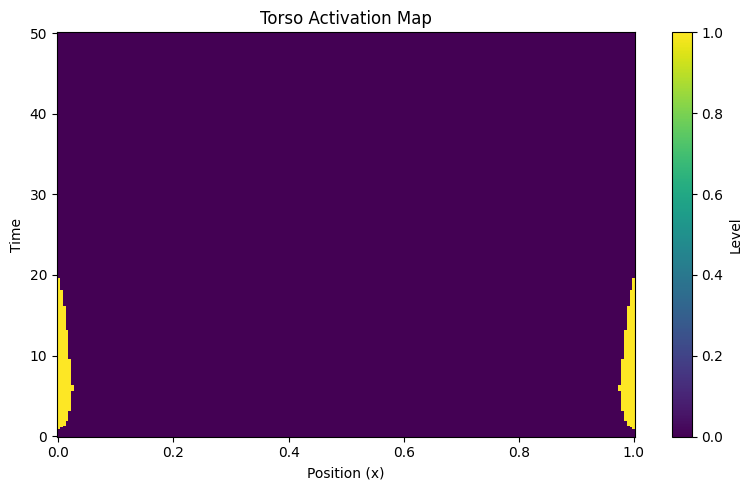

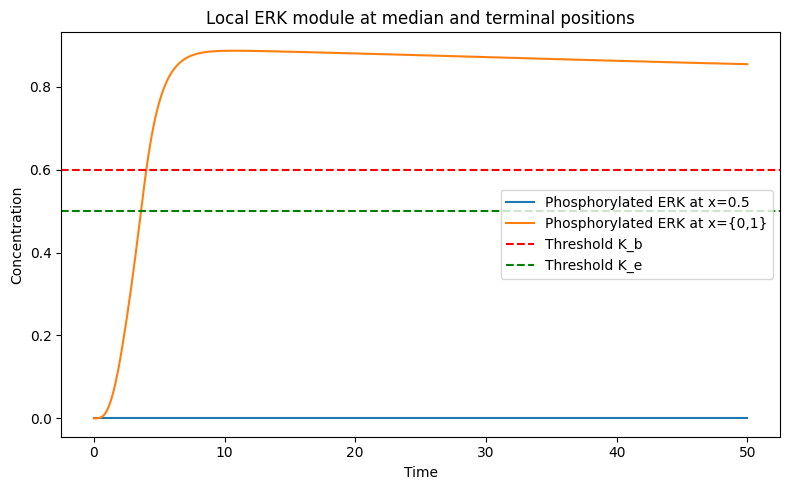

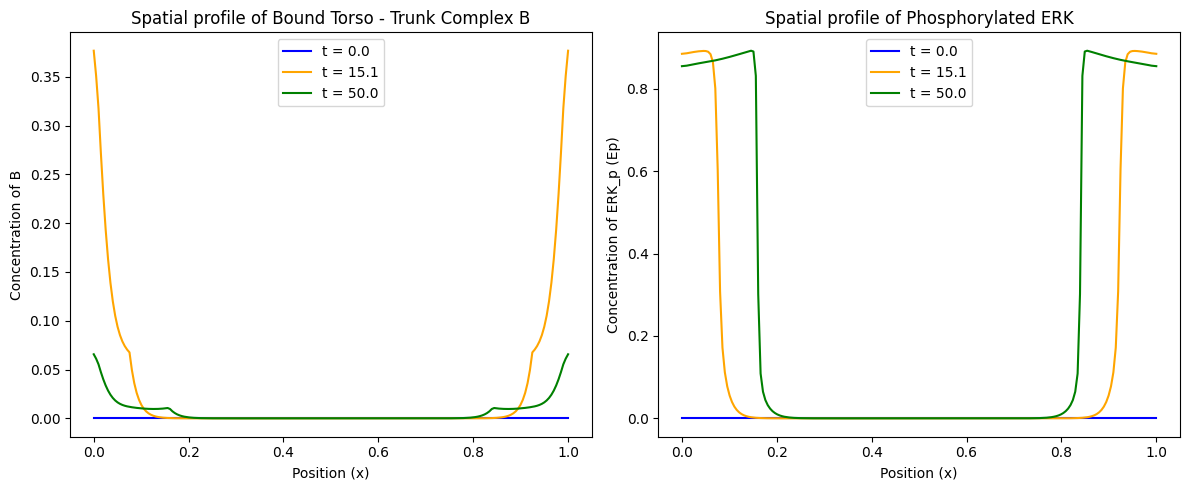

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----- PARAMETERS -----
# Spatial-PDE parameters
D_T = 0.01       # diffusion of inactive trunk
D_A = 0.0005     # diffusion of active trunk
k_cleave = 1.0   # cleavage rate of T to A
k_deg_A = 0.4    # degradation of A
k_on0 = 2.0      # basal binding rate of A to receptor
k_off = 0.05     # unbinding rate of complex B
R_tot = 1.0      # total receptor
threshold = 0.3  # activation threshold for B
T0_total = 1.0   # total initial concentration of Trunk
L = 1.0          # domain length
nx = 200         # spatial grid points
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

t_span = (0.01, 50)
t_eval = np.linspace(*t_span, 300)

# Torso-like ligand profile
def torso_like(x, width=0.01):
    return np.where((x <= width) | (x >= 1 - width), 1.0, 0.0)
TL = torso_like(x, width=dx*2)

# ----- ERK Module parameters -----
V_b = 1         # Raf phosphorylation rate by Torso
V_c = 1.0         # Raf phosphorylation rate by signal C
alpha_r = 0.2     # Dephosphorylation rate of Raf_p
V_e = 1.0         # ERK phosphorylation rate by Raf_p
alpha_e = 0.1     # Dephosphorylation rate of ERK_p
beta0 = 0.01      # Basal production rate of C
beta = 2.0        # Maximal autoregulation rate of C by ERK_p
n = 4             # Hill coefficient for C expression
K_c = 0.4         # Hill constant for C expression
alpha_c = 0.05    # Degradation rate of C protein
K_b = 0.6         # ERK_p threshold to turn off Torso input
K_e = 0.5         # ERK_p threshold for feedback activation
# ----- INITIAL CONDITIONS -----
def initialize():
    # T, A, B fields
    T0 = np.full(nx, T0_total / L)  # uniform trunk
    A0 = np.zeros(nx)
    B0 = np.zeros(nx)
    # Local ODEs: Rp, Ep, C (homogeneous initial)
    Rp0 = np.zeros(nx)
    Ep0 = np.zeros(nx)
    C0 = np.zeros(nx)
    return np.concatenate([T0, A0, B0, Rp0, Ep0, C0])

# ----- SYSTEM: PDE + local ODE at each x -----
def system_full(t, y):
    # unpack
    T = y[0:nx]
    A = y[nx:2*nx]
    B = y[2*nx:3*nx]
    Rp = y[3*nx:4*nx]
    Ep = y[4*nx:5*nx]
    C = y[5*nx:6*nx]

    # allocate derivatives
    dT = np.zeros(nx)
    dA = np.zeros(nx)
    dB = np.zeros(nx)
    dRp = np.zeros(nx)
    dEp = np.zeros(nx)
    dC = np.zeros(nx)

    # Laplacian for diffusion
    def laplacian(u):
        d2 = np.zeros_like(u)
        d2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        return d2

    # Diffusion
    dT += D_T * laplacian(T)
    dA += D_A * laplacian(A)

    # T -> A conversion
    reaction = k_cleave * TL * T
    dT -= reaction
    dA += reaction

    # Binding/unbinding for trunk-receptor complexes
    # k_on is turned off where Ep >= K_b
    k_on_eff = np.where(Ep < K_b, k_on0, 0.0)
    R_free = R_tot - B
    bind = k_on_eff * A * R_free
    unbind = k_off * B
    dA -= (bind - unbind)
    dB += (bind - unbind)

    # Degradation of A
    dA -= k_deg_A * A

    # ----- local ODEs for ERK module at each x -----
    # Note: no diffusion for Rp, Ep, C
    Ro = R_tot - Rp
    Eo = E_tot - Ep
    # local torso-ligand B provides signal b(x)
    b_loc = B
    # effective rates
    Vb_eff = np.where(Ep < K_b, V_b, 0.0)
    beta_eff = np.where(Ep < K_e, beta, 0.0)
    beta0_eff = np.where(Ep >= K_e, beta0, 0.0)

    dRp = Vb_eff * (b_loc/2.0) * Ro + V_c * C * Ro - alpha_r * Rp
    dEp = V_e * Rp * Eo - alpha_e * Ep
    dC  = beta0_eff + beta_eff * Ep**n / (Ep**n + K_c**n) - alpha_c * C

    # pack
    return np.concatenate([dT, dA, dB, dRp, dEp, dC])

# ----- RUN SIMULATION -----
sol = solve_ivp(system_full, t_span, initialize(), t_eval=t_eval, method='RK45')
# unpack solutions
T_sol  = sol.y[0:nx, :]
A_sol  = sol.y[nx:2*nx, :]
B_sol  = sol.y[2*nx:3*nx, :]
Rp_sol = sol.y[3*nx:4*nx, :]
Ep_sol = sol.y[4*nx:5*nx, :]
C_sol  = sol.y[5*nx:6*nx, :]
activation = (B_sol >= threshold).astype(float)

# ----- PLOTTING -----
def plot_spatiotemporal(data, x, t, title, cmap='viridis'):
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(x, t, data.T, shading='auto', cmap=cmap)
    plt.xlabel('Position (x)')
    plt.ylabel('Time')
    plt.title(title)
    plt.colorbar(label='Level')
    plt.tight_layout()
    plt.show()

# Heatmaps
plot_spatiotemporal(T_sol, x, sol.t, "Inactive Trunk T(x,t)")
plot_spatiotemporal(A_sol, x, sol.t, "Active Trunk A(x,t)")
plot_spatiotemporal(B_sol, x, sol.t, "Bound Complex B(x,t)")
plot_spatiotemporal(Ep_sol, x, sol.t, "Phospho-ERK Ep(x,t)")
plot_spatiotemporal(activation, x, sol.t, "Torso Activation Map")

# Time series of ERK_p at median and terminal positions
mid = nx//2
plt.figure(figsize=(8,5))
plt.plot(sol.t, Ep_sol[mid], label='Phosphorylated ERK at x=0.5')
plt.plot(sol.t, Ep_sol[-1], label='Phosphorylated ERK at x={0,1}')
plt.axhline(K_b, ls='--', label='Threshold K_b', color='red')
plt.axhline(K_e, ls='--', label='Threshold K_e', color='green')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.title('Local ERK module at median and terminal positions')
plt.tight_layout()
plt.show()

# ----- SPATIAL LINE PLOTS AT t = 0, 15, 50 -----
times_to_plot = [0, 15, 50]
indices = [np.argmin(np.abs(sol.t - t)) for t in times_to_plot]
colors = ['blue', 'orange', 'green']
labels = [f't = {sol.t[i]:.1f}' for i in indices]

plt.figure(figsize=(12, 5))

# Plot B(x)
plt.subplot(1, 2, 1)
for i, c, label in zip(indices, colors, labels):
    plt.plot(x, B_sol[:, i], color=c, label=label)
plt.xlabel('Position (x)')
plt.ylabel('Concentration of B')
plt.title('Spatial profile of Bound Torso - Trunk Complex B')
plt.legend()

# Plot Ep(x)
plt.subplot(1, 2, 2)
for i, c, label in zip(indices, colors, labels):
    plt.plot(x, Ep_sol[:, i], color=c, label=label)
plt.xlabel('Position (x)')
plt.ylabel('Concentration of ERK_p (Ep)')
plt.title('Spatial profile of Phosphorylated ERK')
plt.legend()

plt.tight_layout()
plt.show()


